# 第8章 静学ゲーム：Berry (1992) による参入ゲームの推定

Berry (1992) の手法を用いて、病院のMRI導入に関する参入ゲームモデルを推定する。
シミュレーションベースの推定手法により、均衡参入企業数を計算し、構造パラメータを推定する。

## 1. Pythonに関する下準備

In [1]:
import numpy as np
import pandas as pd
from scipy import optimize
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import warnings
import time

warnings.filterwarnings('ignore')

# 日本語フォント設定
for font_name in ['Hiragino Maru Gothic Pro', 'Hiragino Sans',
                   'IPAexGothic', 'Noto Sans CJK JP', 'Yu Gothic']:
    try:
        matplotlib.font_manager.findfont(font_name, fallback_to_default=False)
        plt.rcParams['font.family'] = font_name
        break
    except ValueError:
        continue

# パス設定
base_dir = Path('..')
data_dir = base_dir / 'data'
output_dir = base_dir / 'output'
output_dir.mkdir(exist_ok=True)

print("Setup complete.")


Setup complete.


## 2. データの準備

In [2]:
# 病院データを読み込む
data_raw = pd.read_csv(data_dir / 'data_hospital_Berry1992.csv', encoding='utf-8')
print(f"読み込んだデータ: {data_raw.shape[0]} 行, {data_raw.shape[1]} 列")

# ダミー変数を作成
data_cleaned = data_raw.copy()

# 大学（公立、国立、私立大学）ダミー
data_cleaned['DaigakuDum'] = data_cleaned['Management'].isin(
    ['公立大学法人', '国（国立大学法人）', '私立学校法人']
).astype(int)

# 病床数0ダミー
data_cleaned['ZeroBedDum'] = (data_cleaned['NumBeds'] == 0).astype(int)

# 単位の調整と、対数変換した変数の作成
# - NumBeds: 100病床
# - Population: 100万人
# - Menseki: 100km2
# - TaxableIncome: 1000（100万円）
data_cleaned['NumBeds'] = data_cleaned['NumBeds'] / 100
data_cleaned['LogNumBeds'] = np.log(data_cleaned['NumBeds'] + 0.01)
data_cleaned['Population'] = data_cleaned['Population'] / 1e6
data_cleaned['Menseki'] = data_cleaned['Menseki'] / 100
data_cleaned['TaxableIncome'] = data_cleaned['TaxableIncome'] / 1000
data_cleaned['LogPop'] = np.log(data_cleaned['Population'])
data_cleaned['LogIncome'] = np.log(data_cleaned['TaxableIncome'])

print(f"加工後のデータ: {data_cleaned.shape[0]} 行")
data_cleaned.head(3)


読み込んだデータ: 8862 行, 20 列
加工後のデータ: 8862 行


,HospitalID,Prefecture,CityCode,SecondaryAreaName,SecondaryAreaCode,Management,Kyukyu,Kinou,Sien,Hyoka,...,Population,Menseki,PopDensity,TaxableIncome,MRIOwnDum,DaigakuDum,ZeroBedDum,LogNumBeds,LogPop,LogIncome
0,1,北海道,1101,札幌,104.0,共済,1.0,0.0,0.0,0.0,...,0.220189,0.4642,4743.4,3.017,1,0,0,0.891998,-1.513269,1.104263
1,2,北海道,1101,札幌,104.0,財団,0.0,0.0,0.0,0.0,...,0.220189,0.4642,4743.4,3.017,1,0,0,0.593327,-1.513269,1.104263
2,3,北海道,1101,札幌,104.0,医療法人,1.0,0.0,0.0,0.0,...,0.220189,0.4642,4743.4,3.017,1,0,0,0.104360,-1.513269,1.104263


## 3. 企業レベルの変数の記述統計

In [3]:
# MRIを購買した病院と購買していない病院の記述統計
desc_vars = ['Kyukyu', 'Kinou', 'Sien', 'Hyoka',
             'DepNeurology', 'DepNeurosurgery', 'NumBeds',
             'ZeroBedDum', 'DaigakuDum']

desc_stats_list = []
for mri_val in [1, 0]:
    subset = data_cleaned[data_cleaned['MRIOwnDum'] == mri_val]
    for var in desc_vars:
        desc_stats_list.append({
            'skim_variable': var,
            'MRIOwnDum': mri_val,
            'mean': subset[var].mean(),
            'sd': subset[var].std()
        })

desc_df = pd.DataFrame(desc_stats_list)

# ピボットテーブルに変換
tbl_data = desc_df.pivot(index='skim_variable', columns='MRIOwnDum', values=['mean', 'sd'])
tbl_data.columns = ['mean_0', 'mean_1', 'sd_0', 'sd_1']
tbl_data = tbl_data[['mean_1', 'sd_1', 'mean_0', 'sd_0']]
tbl_data = tbl_data.loc[desc_vars].reset_index()

# 日本語のラベルを付与
jp_labels = ['救急', '機能', '支援', '評価', '神経内科', '神経外科',
             '病床数', '病床0', '大学病院']
tbl_data['skim_variable'] = jp_labels

print("記述統計:")
print(tbl_data.to_string(index=False))

# CSVで保存
tbl_data.to_csv(output_dir / 'Tab8_6_descriptive_stats.csv', index=False, encoding='utf-8')
print("\n保存先: output/Tab8_6_descriptive_stats.csv")


記述統計:
skim_variable   mean_1     sd_1   mean_0     sd_0
           救急 0.711693 0.453042 0.302131 0.459223
           機能 0.019946 0.139837 0.002550 0.050434
           支援 0.047633 0.213021 0.004007 0.063176
           評価 0.433462 0.495627 0.169368 0.375111
         神経内科 0.393081 0.488507 0.121991 0.327306
         神経外科 0.569643 0.495200 0.082119 0.274572
          病床数 2.077281 1.941498 0.391861 0.710501
          病床0 0.058247 0.234244 0.450791 0.497618
         大学病院 0.041605 0.199714 0.004548 0.067291

保存先: output/Tab8_6_descriptive_stats.csv


In [4]:
# 各カテゴリーの病院のMRI保有割合
def per_MRI_cal(df):
    total = len(df)
    mri_hos = df['MRIOwnDum'].sum()
    per_mri = round(mri_hos / total * 100, 2) if total > 0 else 0
    return {'Total': total, 'MRIHos': int(mri_hos), 'PerMRI': per_mri}

categories = {
    'All': data_cleaned,
    'Kyukyu': data_cleaned[data_cleaned['Kyukyu'] == 1],
    'Sien': data_cleaned[data_cleaned['Sien'] == 1],
    'Hyoka': data_cleaned[data_cleaned['Hyoka'] == 1],
    'DepNeurology': data_cleaned[data_cleaned['DepNeurology'] == 1],
    'DepNeurosurgery': data_cleaned[data_cleaned['DepNeurosurgery'] == 1],
    'Top25%_NumBeds': data_cleaned[data_cleaned['LogNumBeds'] >= np.log(1.2)],
    'DaigakuDum': data_cleaned[data_cleaned['DaigakuDum'] == 1],
    'ZeroBedDum': data_cleaned[data_cleaned['ZeroBedDum'] == 1],
}

mri_table = pd.DataFrame([
    {'Category': k, **per_MRI_cal(v)} for k, v in categories.items()
])
print("各カテゴリーの病院のMRI保有割合:")
print(mri_table.to_string(index=False))


各カテゴリーの病院のMRI保有割合:
       Category  Total  MRIHos  PerMRI
            All   8862    3365   37.97
         Kyukyu   4051    2392   59.05
           Sien    182     160   87.91
          Hyoka   2386    1456   61.02
   DepNeurology   1987    1318   66.33
DepNeurosurgery   2365    1914   80.93
 Top25%_NumBeds   2264    1932   85.34
     DaigakuDum    165     140   84.85
     ZeroBedDum   2674     196    7.33


## 4. Berry (1992) による推定

### 推定のためのデータ加工

- Step 0: 欠損のあるデータを削除
- Step 1: シミュレーションに必要な変数を作成、参入の順番に並び替え
- Step 2: 潜在的参入病院数を絞ってサブサンプル
- Step 3: シミュレーションを行いやすくするためにデータを縦に長く加工

In [5]:
def berry_process_data(df):
    """
    推定のためにデータを加工する関数。
    - 各病院に乱数を振る (TieEntryOrder)
    - 自治体毎の潜在的参入病院数・観察された参入病院数を計算
    - 病床数が多い順に並び替え、参入順序IDを振る
    """
    df = df.copy()
    df = df.sort_values('CityCode').reset_index(drop=True)

    # 各病院に乱数を振る
    df['TieEntryOrder'] = np.random.uniform(size=len(df))

    # 自治体毎の潜在的参入病院数、観察された参入病院数
    df['NumPotenHos'] = df.groupby('CityCode')['CityCode'].transform('count')
    df['NumEntryObs'] = df.groupby('CityCode')['MRIOwnDum'].transform('sum')

    # 病床数が多い順に並び替え（タイは乱数参照）
    df = df.sort_values(
        ['CityCode', 'LogNumBeds', 'TieEntryOrder'],
        ascending=[True, False, False]
    ).reset_index(drop=True)

    # 自治体毎に参入順序IDを振る
    df['EntryOrderId'] = df.groupby('CityCode').cumcount() + 1

    return df


def berry_expand_data(df, ns):
    """
    シミュレーションを行いやすくするためにデータを縦に長く加工する関数。
    データの行数は sum(Im * Im) * ns となる。
    """
    # 自治体の数
    M = df['CityCode'].nunique()

    # 自治体コードのリスト（ソート済み）
    city_codes = df['CityCode'].unique()
    city_codes.sort()

    # 各自治体の病院数
    city_hos_counts = df.groupby('CityCode').size().to_dict()

    # 病院の総数
    NumHos = len(df)

    # --- 誤差項をシミュレーション ---
    # u_m0: 自治体レベルの誤差項 (M * ns)
    u_m0_draws = np.random.normal(0, 1, size=M * ns)
    # u_mIm: 病院レベルの誤差項 (NumHos * ns)
    u_mIm_draws = np.random.normal(0, 1, size=NumHos * ns)

    # --- 誤差項のDataFrameを作成 ---
    # 自治体毎・シミュレーション番号毎に u_m0 を割り当て
    u_m0_records = []
    idx_m0 = 0
    for city in city_codes:
        for s in range(1, ns + 1):
            u_m0_records.append({'CityCode': city, 's': s, 'u_m0': u_m0_draws[idx_m0]})
            idx_m0 += 1

    u_m0_df = pd.DataFrame(u_m0_records)

    # 病院毎・シミュレーション番号毎に u_mIm を割り当て
    # R の nest/crossing/unnest と同じ順序: CityCode でグループ化し、各グループ内で s=1..ns を展開
    u_mIm_records = []
    idx_mIm = 0
    for city in city_codes:
        city_data = df[df['CityCode'] == city][['CityCode', 'EntryOrderId']]
        for s in range(1, ns + 1):
            for _, row in city_data.iterrows():
                u_mIm_records.append({
                    'CityCode': row['CityCode'],
                    'EntryOrderId': row['EntryOrderId'],
                    's': s,
                    'u_mIm': u_mIm_draws[idx_mIm]
                })
                idx_mIm += 1

    u_mIm_df = pd.DataFrame(u_mIm_records)

    # u_m0 と u_mIm を結合
    u_df = u_mIm_df.merge(u_m0_df, on=['CityCode', 's'], how='left')

    # 元のデータに誤差項を結合
    data_expand = df.merge(u_df, on=['CityCode', 'EntryOrderId'], how='left')

    # --- n_cand の変数を作成 ---
    # 自治体毎、病院毎に 1 から NumPotenHos までの候補数を振る
    n_cand_records = []
    for city in city_codes:
        city_data = df[df['CityCode'] == city]
        num_poten = len(city_data)
        for _, row in city_data.iterrows():
            for n in range(1, num_poten + 1):
                n_cand_records.append({
                    'CityCode': row['CityCode'],
                    'EntryOrderId': row['EntryOrderId'],
                    'n_cand': n
                })

    n_cand_df = pd.DataFrame(n_cand_records)

    data_expand = data_expand.merge(n_cand_df, on=['CityCode', 'EntryOrderId'], how='left')

    return data_expand


print("関数定義完了: berry_process_data, berry_expand_data")


関数定義完了: berry_process_data, berry_expand_data


In [6]:
# Step 0: 欠損のあるデータを削除
cols_needed = ['CityCode', 'Kyukyu', 'Kinou', 'Sien', 'Hyoka',
               'DepNeurology', 'DepNeurosurgery', 'LogNumBeds',
               'ZeroBedDum', 'DaigakuDum',
               'Menseki', 'LogPop', 'LogIncome',
               'MRIOwnDum']

data_processed_pre = data_cleaned[cols_needed].dropna().copy()
print(f"Step 0 (欠損削除後): {len(data_processed_pre)} 行")

# Step 1: シミュレーションに必要な変数を作成
np.random.seed(1)
data_processed = berry_process_data(data_processed_pre)
del data_processed_pre

# Step 2: 潜在的参入病院数を絞ってサブサンプル
NumPotenHos_max = 4
data_processed = data_processed[data_processed['EntryOrderId'] <= NumPotenHos_max].copy()

# NumEntryObs, NumPotenHos の値を更新
data_processed['NumEntryObs'] = data_processed.groupby('CityCode')['MRIOwnDum'].transform('sum')
data_processed['NumPotenHos'] = data_processed.groupby('CityCode')['CityCode'].transform('count')

print(f"Step 2 (サブサンプル後): {len(data_processed)} 行")
print(f"自治体数: {data_processed['CityCode'].nunique()}")

# 各カテゴリーの病院のMRI保有割合（サブサンプル後のデータ）
categories_sub = {
    'All': data_processed,
    'Kyukyu': data_processed[data_processed['Kyukyu'] == 1],
    'Sien': data_processed[data_processed['Sien'] == 1],
    'Hyoka': data_processed[data_processed['Hyoka'] == 1],
    'DepNeurology': data_processed[data_processed['DepNeurology'] == 1],
    'DepNeurosurgery': data_processed[data_processed['DepNeurosurgery'] == 1],
    'Top25%_NumBeds': data_processed[data_processed['LogNumBeds'] >= np.log(1.2)],
    'DaigakuDum': data_processed[data_processed['DaigakuDum'] == 1],
    'ZeroBedDum': data_processed[data_processed['ZeroBedDum'] == 1],
}

mri_table_sub = pd.DataFrame([
    {'Category': k, **per_MRI_cal(v)} for k, v in categories_sub.items()
])
print("\n各カテゴリーの病院のMRI保有割合（サブサンプル後）:")
print(mri_table_sub.to_string(index=False))


Step 0 (欠損削除後): 8628 行
Step 2 (サブサンプル後): 4112 行
自治体数: 1457

各カテゴリーの病院のMRI保有割合（サブサンプル後）:
       Category  Total  MRIHos  PerMRI
            All   4112    2251   54.74
         Kyukyu   2474    1744   70.49
           Sien    151     141   93.38
          Hyoka   1425    1096   76.91
   DepNeurology   1279    1015   79.36
DepNeurosurgery   1694    1471   86.84
 Top25%_NumBeds   1857    1629   87.72
     DaigakuDum    124     114   91.94
     ZeroBedDum    646      47    7.28


In [7]:
# Step 3: データを加工する
ns = 100

print("データを展開中...")
tic = time.time()
data_expand = berry_expand_data(data_processed, ns)
toc = time.time()
print(f"展開後のデータ: {len(data_expand)} 行")
print(f"所要時間: {toc - tic:.1f} 秒")


データを展開中...


展開後のデータ: 1399400 行
所要時間: 7.3 秒


### 目的関数の定義と推定

In [8]:
def berry_obj(params, df):
    """
    データとパラメータを所与としたBerry (1992) の目的関数の値を計算する。

    均衡参入企業数の計算:
    1. 均衡参入数の候補 n_cand を所与として、各企業が参入するかを決定。
       その結果の参入数を n_sim とする。
    2. n_cand > n_sim ならば、n_cand は均衡における参入数ではない。
    3. n_cand <= n_sim が成立する n_cand の中で最大のものを均衡参入数 N* とする。
    """
    # パラメータ
    alpha = params[:8]
    beta = params[8:12]
    delta = params[12]
    rho = params[13]

    # 可変利潤、固定費用の作成（本誌のvとphiに対応）
    var_profit = (beta[0]
                  + beta[1] * df['Menseki'].values
                  + beta[2] * df['LogPop'].values
                  + beta[3] * df['LogIncome'].values
                  - delta * np.log(df['n_cand'].values)
                  + rho * df['u_m0'].values)

    fixed_cost = (alpha[0] * df['Kyukyu'].values
                  + alpha[1] * df['Sien'].values
                  + alpha[2] * df['Hyoka'].values
                  + alpha[3] * df['DepNeurology'].values
                  + alpha[4] * df['DepNeurosurgery'].values
                  + alpha[5] * df['LogNumBeds'].values
                  + alpha[6] * df['ZeroBedDum'].values
                  + alpha[7] * df['DaigakuDum'].values
                  - np.sqrt(1 - rho**2) * df['u_mIm'].values)

    # 参入するかどうかの判定
    entry_decision = (var_profit > fixed_cost).astype(int)

    # グループ毎に参入企業数を集計
    # 高速化のため、pandas の groupby を使用
    work = pd.DataFrame({
        'CityCode': df['CityCode'].values,
        'NumEntryObs': df['NumEntryObs'].values,
        's': df['s'].values,
        'n_cand': df['n_cand'].values,
        'EntryDecision': entry_decision
    })

    # (CityCode, s, n_cand) 毎に参入企業数を集計
    grp1 = work.groupby(['CityCode', 'NumEntryObs', 's', 'n_cand'], sort=False).agg(
        n_sim=('EntryDecision', 'sum')
    ).reset_index()

    # 均衡条件: n_sim >= n_cand
    grp1['n_star'] = np.where(grp1['n_sim'] >= grp1['n_cand'], grp1['n_cand'], 0)

    # (CityCode, s) 毎に n_star の最大値を取る
    grp2 = grp1.groupby(['CityCode', 'NumEntryObs', 's'], sort=False).agg(
        n_star=('n_star', 'max')
    ).reset_index()

    # (CityCode) 毎に期待参入企業数を計算
    grp3 = grp2.groupby(['CityCode', 'NumEntryObs'], sort=False).agg(
        n_exp=('n_star', 'mean')
    ).reset_index()

    # MSE
    mse = np.mean((grp3['NumEntryObs'].values - grp3['n_exp'].values) ** 2)

    return mse


print("関数定義完了: berry_obj")


関数定義完了: berry_obj


In [9]:
# 係数の名前
est_names = ['Kyukyu', 'Sien', 'Hyoka',
             'DepNeurology', 'DepNeurosurgery', 'LogNumBeds',
             'ZeroBedDum', 'DaigakuDum', 'Constant',
             'Menseki', 'LogPop', 'LogIncome',
             'delta', 'rho']

# 初期値
param_init = np.array([
    -0.587617, -1.298752, -0.556557,
    -0.502602, -1.058680, -0.919110,
    -2.832720, -2.726932,  1.937292,
     0.009940,  0.206644, -1.617755,
     0.550239,  0.132202
])

# 推定を行う
print("Berry (1992) の推定を開始...")
tic = time.time()

berry_result = optimize.minimize(
    berry_obj,
    param_init,
    args=(data_expand,),
    method='Nelder-Mead',
    options={'maxiter': 100000, 'xatol': 1e-8, 'fatol': 1e-8}
)

toc = time.time()
print(f"推定完了: {toc - tic:.1f} 秒")
print(f"目的関数の値: {berry_result.fun:.6f}")
print(f"収束: {berry_result.success}")

# rhoの符号を正しくする
berry_est = berry_result.x.copy()
berry_est[13] = abs(berry_est[13])

print("\n推定結果:")
for name, val in zip(est_names, berry_est):
    print(f"  {name:20s}: {val:.6f}")


Berry (1992) の推定を開始...


推定完了: 70.1 秒
目的関数の値: 0.367884
収束: True

推定結果:
  Kyukyu              : -0.573699
  Sien                : -1.329308
  Hyoka               : -0.551630
  DepNeurology        : -0.497985
  DepNeurosurgery     : -1.103328
  LogNumBeds          : -0.950109
  ZeroBedDum          : -2.819199
  DaigakuDum          : -2.803777
  Constant            : 1.936496
  Menseki             : 0.010113
  LogPop              : 0.208209
  LogIncome           : -1.610764
  delta               : 0.537001
  rho                 : 0.124749


### Bootstrapによる標準誤差の計算

In [10]:
# ブートストラップの回数
# 注意: R版では n_bootstrap=100 だが、Python版では計算時間の制約のため20に削減
# R版と同じ結果を得るには n_bootstrap=100 に変更してください
n_bootstrap = 20

# 自治体の数
M = data_processed['CityCode'].nunique()
city_list = data_processed['CityCode'].unique()

print(f"Bootstrap: {n_bootstrap} 回, 自治体数: {M}")
print("Bootstrap推定を開始...")

np.random.seed(12345)
bs_results = []

tic_all = time.time()
for i in range(n_bootstrap):
    tic_i = time.time()

    # リサンプルを行う（自治体単位で復元抽出）
    bs_cities = np.random.choice(city_list, size=M, replace=True)
    bs_cities_sorted = np.sort(bs_cities)

    # リサンプルした自治体のデータを結合
    bs_data_list = []
    for new_id, city in enumerate(bs_cities_sorted, 1):
        city_data = data_processed[data_processed['CityCode'] == city].copy()
        city_data['CityCodeOrigin'] = city_data['CityCode']
        city_data['CityCode'] = new_id
        bs_data_list.append(city_data)

    bs_data = pd.concat(bs_data_list, ignore_index=True)

    # リサンプルしたデータを推定のために加工
    bs_data_processed = berry_process_data(bs_data)

    # 先程と同様に推定のためにデータを縦に広げる
    bs_data_expand = berry_expand_data(bs_data_processed, ns)

    # 先程と同様に最適化により推定
    try:
        bs_result = optimize.minimize(
            berry_obj,
            param_init,
            args=(bs_data_expand,),
            method='Nelder-Mead',
            options={'maxiter': 100000, 'xatol': 1e-8, 'fatol': 1e-8}
        )
        bs_par = bs_result.x.copy()
        # rhoの符号を正しくする
        bs_par[13] = abs(bs_par[13])
        bs_results.append(bs_par)
    except Exception as e:
        print(f"  Bootstrap {i+1}: エラー - {e}")
        continue

    toc_i = time.time()
    if (i + 1) % 10 == 0:
        print(f"  Bootstrap {i+1}/{n_bootstrap} 完了 ({toc_i - tic_i:.1f} 秒)")

toc_all = time.time()
print(f"\nBootstrap完了: {toc_all - tic_all:.1f} 秒")

# 標準誤差を計算
bs_array = np.array(bs_results)
berry_se = np.std(bs_array, axis=0, ddof=0)

print("\nBootstrap標準誤差:")
for name, se_val in zip(est_names, berry_se):
    print(f"  {name:20s}: {se_val:.6f}")


Bootstrap: 20 回, 自治体数: 1457
Bootstrap推定を開始...


  Bootstrap 10/20 完了 (76.3 秒)


  Bootstrap 20/20 完了 (88.4 秒)

Bootstrap完了: 1704.2 秒

Bootstrap標準誤差:
  Kyukyu              : 0.065325
  Sien                : 0.045709
  Hyoka               : 0.035193
  DepNeurology        : 0.068979
  DepNeurosurgery     : 0.087144
  LogNumBeds          : 0.073518
  ZeroBedDum          : 0.381799
  DaigakuDum          : 0.154298
  Constant            : 0.160929
  Menseki             : 0.000445
  LogPop              : 0.011993
  LogIncome           : 0.130528
  delta               : 0.038322
  rho                 : 0.009625


## 5. 推定結果

In [11]:
# 推定結果のテーブルを作成
jp_est_names = ['救急', '支援', '評価', '神経内科', '神経外科',
                'log(病床数)', '病床0', '大学病院',
                '定数項', '面積', 'log(人口)', 'log(課税所得)',
                'delta', 'rho', '目的関数の値']

tbl_est = pd.DataFrame({
    'name': jp_est_names,
    'Berry_est': list(berry_est) + [berry_result.fun],
    'Berry_SE': list(berry_se) + [np.nan]
})

print("Berry (1992) による推定結果:")
print(tbl_est.to_string(index=False))

# CSVで保存
tbl_est.to_csv(output_dir / 'Tab8_7_Berry1992_Est.csv', index=False, encoding='utf-8')
print("\n保存先: output/Tab8_7_Berry1992_Est.csv")


Berry (1992) による推定結果:
     name  Berry_est  Berry_SE
       救急  -0.573699  0.065325
       支援  -1.329308  0.045709
       評価  -0.551630  0.035193
     神経内科  -0.497985  0.068979
     神経外科  -1.103328  0.087144
 log(病床数)  -0.950109  0.073518
      病床0  -2.819199  0.381799
     大学病院  -2.803777  0.154298
      定数項   1.936496  0.160929
       面積   0.010113  0.000445
  log(人口)   0.208209  0.011993
log(課税所得)  -1.610764  0.130528
    delta   0.537001  0.038322
      rho   0.124749  0.009625
   目的関数の値   0.367884       NaN

保存先: output/Tab8_7_Berry1992_Est.csv


### モデルによる予測の確認

In [12]:
def predict_model(df):
    """
    モデルによる参入予測確率を含めたDataFrameを作成する。
    参入企業数の計算方法は berry_obj と同じ。
    EntryOrderId に基づいて、どの病院が参入するかを決定する。
    """
    # 参入判定
    entry_decision = (df['var_profit'] > df['fixed_cost']).astype(int)

    work = pd.DataFrame({
        'CityCode': df['CityCode'].values,
        'NumEntryObs': df['NumEntryObs'].values,
        's': df['s'].values,
        'n_cand': df['n_cand'].values,
        'EntryDecision': entry_decision
    })

    # (CityCode, s, n_cand) 毎に参入企業数を集計
    grp1 = work.groupby(['CityCode', 'NumEntryObs', 's', 'n_cand'], sort=False).agg(
        n_sim=('EntryDecision', 'sum')
    ).reset_index()

    # 均衡条件
    grp1['n_star'] = np.where(grp1['n_sim'] >= grp1['n_cand'], grp1['n_cand'], 0)

    # (CityCode, s) 毎に n_star の最大値
    grp2 = grp1.groupby(['CityCode', 'NumEntryObs', 's'], sort=False).agg(
        n_star=('n_star', 'max')
    ).reset_index()

    # 元のデータから (CityCode, s, EntryOrderId) のユニークな組み合わせを取得
    df_unique = df.drop(columns=['n_cand']).drop_duplicates().copy()

    # n_star を結合
    df_with_nstar = df_unique.merge(
        grp2[['CityCode', 's', 'n_star']],
        on=['CityCode', 's'],
        how='left'
    )

    # 参入順序の仮定に基づいて、それぞれの企業が参入するかどうかを決める
    df_with_nstar['EntryCond'] = (df_with_nstar['n_star'] >= df_with_nstar['EntryOrderId']).astype(int)

    # 参入の予測確率を計算
    entry_prob = df_with_nstar.groupby(['CityCode', 'EntryOrderId']).agg(
        EntryProb=('EntryCond', 'mean')
    ).reset_index()
    entry_prob['EntryPred'] = (entry_prob['EntryProb'] >= 0.5).astype(int)

    # 元のデータ（シミュレーション変数を除いたユニーク行）に結合
    cols_to_drop = ['s', 'u_m0', 'u_mIm', 'n_cand', 'var_profit', 'fixed_cost']
    cols_existing = [c for c in cols_to_drop if c in df.columns]
    df_base = df.drop(columns=cols_existing).drop_duplicates()

    data_predicted = df_base.merge(entry_prob, on=['CityCode', 'EntryOrderId'], how='left')

    return data_predicted


print("関数定義完了: predict_model")


関数定義完了: predict_model


In [13]:
# 推定したパラメータを取得
alpha = berry_est[:8]
beta = berry_est[8:12]
delta = berry_est[12]
rho = berry_est[13]

# var_profit, fixed_cost を計算
data_expand['var_profit'] = (
    beta[0]
    + beta[1] * data_expand['Menseki']
    + beta[2] * data_expand['LogPop']
    + beta[3] * data_expand['LogIncome']
    - delta * np.log(data_expand['n_cand'])
    + rho * data_expand['u_m0']
)

data_expand['fixed_cost'] = (
    alpha[0] * data_expand['Kyukyu']
    + alpha[1] * data_expand['Sien']
    + alpha[2] * data_expand['Hyoka']
    + alpha[3] * data_expand['DepNeurology']
    + alpha[4] * data_expand['DepNeurosurgery']
    + alpha[5] * data_expand['LogNumBeds']
    + alpha[6] * data_expand['ZeroBedDum']
    + alpha[7] * data_expand['DaigakuDum']
    - np.sqrt(1 - rho**2) * data_expand['u_mIm']
)

# モデルの予測を計算
data_predicted = predict_model(data_expand)

# 参入病院数毎に、自治体がいくつ観察されるかを集計
city_summary = data_predicted.groupby('CityCode').agg(
    Actual=('MRIOwnDum', 'sum'),
    Predict=('EntryPred', 'sum')
).reset_index()

print("参入病院数の分布 (Actual vs Predict):")
print(city_summary[['Actual', 'Predict']].describe().to_string())


参入病院数の分布 (Actual vs Predict):
            Actual      Predict
count  1457.000000  1457.000000
mean      1.544955     1.555251
std       1.302814     1.242506
min       0.000000     0.000000
25%       0.000000     1.000000
50%       1.000000     1.000000
75%       2.000000     2.000000
max       4.000000     4.000000


病院タイプ別の参入病院数 (Actual vs Predict):
       Category  Actual  Predict
            All    2251     2266
         Kyukyu    1744     1804
           Sien     141      149
          Hyoka    1096     1164
   DepNeurology    1015     1047
DepNeurosurgery    1471     1533
 Top25%_NumBeds    1629     1794
     DaigakuDum     114      124
     ZeroBedDum      47        0


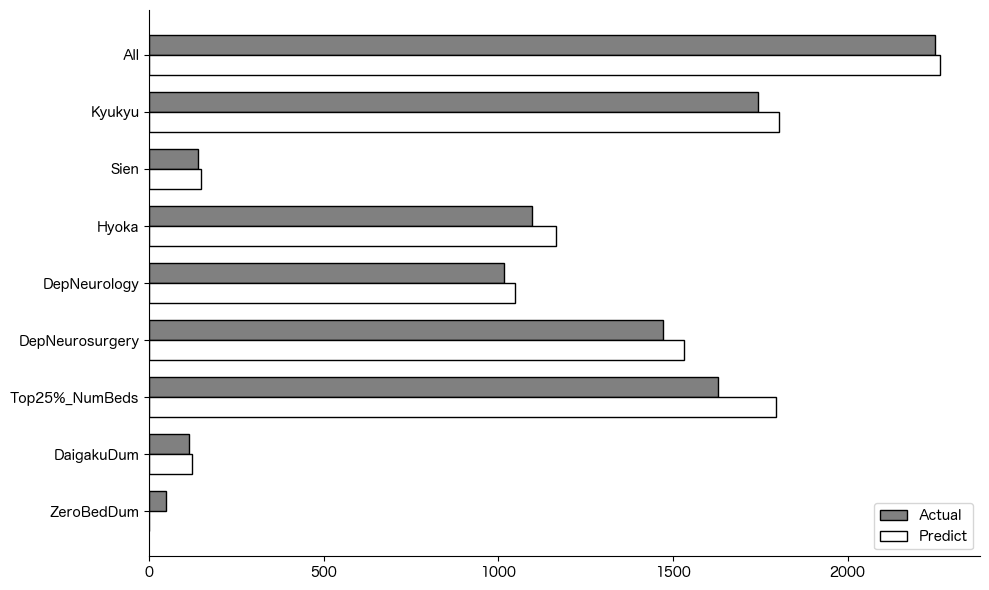

In [14]:
# 病院のタイプ別の観察された参入病院数と予測された参入病院数
def actual_pred_cal(df):
    return {
        'Actual': int(df['MRIOwnDum'].sum()),
        'Predict': int(df['EntryPred'].sum())
    }

categories_pred = {
    'All': data_predicted,
    'Kyukyu': data_predicted[data_predicted['Kyukyu'] == 1],
    'Sien': data_predicted[data_predicted['Sien'] == 1],
    'Hyoka': data_predicted[data_predicted['Hyoka'] == 1],
    'DepNeurology': data_predicted[data_predicted['DepNeurology'] == 1],
    'DepNeurosurgery': data_predicted[data_predicted['DepNeurosurgery'] == 1],
    'Top25%_NumBeds': data_predicted[data_predicted['LogNumBeds'] >= np.log(1.2)],
    'DaigakuDum': data_predicted[data_predicted['DaigakuDum'] == 1],
    'ZeroBedDum': data_predicted[data_predicted['ZeroBedDum'] == 1],
}

pred_table = pd.DataFrame([
    {'Category': k, **actual_pred_cal(v)} for k, v in categories_pred.items()
])

print("病院タイプ別の参入病院数 (Actual vs Predict):")
print(pred_table.to_string(index=False))

# 棒グラフ
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(pred_table))
width = 0.35
ax.barh(x - width/2, pred_table['Actual'], width, label='Actual', color='grey', edgecolor='black')
ax.barh(x + width/2, pred_table['Predict'], width, label='Predict', color='white', edgecolor='black')
ax.set_yticks(x)
ax.set_yticklabels(pred_table['Category'])
ax.legend()
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(output_dir / 'Fig8_3_Fit.png', dpi=150)
plt.show()


In [15]:
# 特定の病院について平均二乗誤差を表示
mse_categories = {
    'Total': data_predicted,
    'DepNeurology': data_predicted[data_predicted['DepNeurology'] == 1],
    'DepNeurosurgery': data_predicted[data_predicted['DepNeurosurgery'] == 1],
    'ZeroBedDum': data_predicted[data_predicted['ZeroBedDum'] == 1],
    'DaigakuDum': data_predicted[data_predicted['DaigakuDum'] == 1],
}

mse_table = pd.DataFrame([
    {'Category': k, 'MSE': round(np.mean((v['MRIOwnDum'] - v['EntryProb'])**2), 3)}
    for k, v in mse_categories.items()
])

print("カテゴリー別の平均二乗誤差:")
print(mse_table.to_string(index=False))


カテゴリー別の平均二乗誤差:
       Category   MSE
          Total 0.149
   DepNeurology 0.123
DepNeurosurgery 0.118
     ZeroBedDum 0.070
     DaigakuDum 0.073


## 6. 反実仮想分析

推定では企業の参入順序を仮定する必要がなかったが、反実仮想分析においては、どの企業が参入するかを観察したいため、企業の参入順序を仮定する必要がある。

以下では3つの参入順序を考えて分析を行う:
1. 病床数が多い順
2. 既存企業（データ上で参入が観察された企業）から行動
3. ランダム

In [16]:
def generate_cf_result(data_predicted_input, data_cf):
    """
    反実仮想分析の結果を生成する関数。
    病院のカテゴリー毎に、モデル予測MRI所有病院数と反実仮想分析予測病院数を集計。
    """
    # 元のモデルでの参入の予測を加える
    fit_pred_df = data_predicted_input[['CityCode', 'TieEntryOrder', 'EntryPred']].copy()
    fit_pred_df = fit_pred_df.rename(columns={'EntryPred': 'Fit_Pred'})

    data_cf_sub = data_cf.merge(fit_pred_df, on=['CityCode', 'TieEntryOrder'], how='left')

    # 政策の対象かどうかを表すダミー
    data_cf_sub['PolicyTarget'] = (
        ((data_cf_sub['DepNeurology'] == 1) | (data_cf_sub['DepNeurosurgery'] == 1))
        & (data_cf_sub['Fit_Pred'] != 1)
    ).astype(int)

    # 政策対象を除外
    data_cf_sub = data_cf_sub[data_cf_sub['PolicyTarget'] == 0].copy()

    def per_decline_cal(df_sub):
        return {
            'Fit_Pred': int(df_sub['Fit_Pred'].sum()),
            'CF_Pred': int(df_sub['EntryPred'].sum()),
        }

    cat_list = {
        'All': data_cf_sub,
        'Kyukyu': data_cf_sub[data_cf_sub['Kyukyu'] == 1],
        'Sien': data_cf_sub[data_cf_sub['Sien'] == 1],
        'Hyoka': data_cf_sub[data_cf_sub['Hyoka'] == 1],
        'DepNeurology': data_cf_sub[data_cf_sub['DepNeurology'] == 1],
        'DepNeurosurgery': data_cf_sub[data_cf_sub['DepNeurosurgery'] == 1],
        'Not_(DepNeurology_and_DepNeurosurgery)': data_cf_sub[
            ~((data_cf_sub['DepNeurology'] == 1) | (data_cf_sub['DepNeurosurgery'] == 1))
        ],
        'Top25%_NumBeds': data_cf_sub[data_cf_sub['LogNumBeds'] >= np.log(1.2)],
        'DaigakuDum': data_cf_sub[data_cf_sub['DaigakuDum'] == 1],
        'ZeroBedDum': data_cf_sub[data_cf_sub['ZeroBedDum'] == 1],
    }

    tbl = pd.DataFrame([
        {'Category': k, **per_decline_cal(v)} for k, v in cat_list.items()
    ])
    tbl['PerChange'] = round((tbl['CF_Pred'] / tbl['Fit_Pred'] - 1) * 100, 2)

    return tbl


print("関数定義完了: generate_cf_result")


関数定義完了: generate_cf_result


### 参入順序: 病床数

In [17]:
# 病床数が多い順に参入すると仮定する。タイはランダムとしている。
# 神経内科と神経外科を持つ病院はMRIの所有を義務付けられたとする

data_cf_order1 = data_expand.copy()

# (CityCode, s, n_cand) 毎にMRI所有義務化病院が先になるように並び替え
data_cf_order1 = data_cf_order1.sort_values(
    ['CityCode', 's', 'n_cand',
     'DepNeurology', 'DepNeurosurgery', 'LogNumBeds', 'TieEntryOrder'],
    ascending=[True, True, True, False, False, False, False]
).reset_index(drop=True)

# 参入する順番を更新する
data_cf_order1['EntryOrderId'] = data_cf_order1.groupby(
    ['CityCode', 's', 'n_cand']
).cumcount() + 1

# MRI所有義務化病院の利潤を大きな値に置き換え
mask_mandate = (data_cf_order1['DepNeurology'] == 1) | (data_cf_order1['DepNeurosurgery'] == 1)
data_cf_order1.loc[mask_mandate, 'var_profit'] = 1e5

# 予測
data_cf_1 = predict_model(data_cf_order1)

# Counterfactualの結果をレポート
tbl1 = generate_cf_result(data_predicted, data_cf_1)

print("反実仮想分析の結果（参入順序: 病床数）:")
print(tbl1.to_string(index=False))

# CSVで保存
tbl1.to_csv(output_dir / 'Tab8_8_CF_Simu.csv', index=False, encoding='utf-8')
print("\n保存先: output/Tab8_8_CF_Simu.csv")


反実仮想分析の結果（参入順序: 病床数）:
                              Category  Fit_Pred  CF_Pred  PerChange
                                   All      2266     2179      -3.84
                                Kyukyu      1804     1772      -1.77
                                  Sien       149      149       0.00
                                 Hyoka      1164     1145      -1.63
                          DepNeurology      1047     1047       0.00
                       DepNeurosurgery      1533     1533       0.00
Not_(DepNeurology_and_DepNeurosurgery)       486      399     -17.90
                        Top25%_NumBeds      1794     1771      -1.28
                            DaigakuDum       124      124       0.00
                            ZeroBedDum         0        0        NaN

保存先: output/Tab8_8_CF_Simu.csv


### 参入順序: 既存企業

In [18]:
# 既存企業から行動すると仮定する。タイはランダムとしている。

# --- 元のモデルでの予測 (参入順序: 既存企業) ---
data_pred_order2 = data_expand.copy()

# 既存企業、病床数の順に並び替え
data_pred_order2 = data_pred_order2.sort_values(
    ['CityCode', 's', 'n_cand',
     'MRIOwnDum', 'LogNumBeds', 'TieEntryOrder'],
    ascending=[True, True, True, False, False, False]
).reset_index(drop=True)

data_pred_order2['EntryOrderId'] = data_pred_order2.groupby(
    ['CityCode', 's', 'n_cand']
).cumcount() + 1

data_predicted_order2 = predict_model(data_pred_order2)

# --- 反実仮想分析 (参入順序: 既存企業) ---
data_cf_order2 = data_expand.copy()

# MRI所有義務化病院が先、次に既存企業
data_cf_order2 = data_cf_order2.sort_values(
    ['CityCode', 's', 'n_cand',
     'DepNeurology', 'DepNeurosurgery', 'MRIOwnDum', 'LogNumBeds', 'TieEntryOrder'],
    ascending=[True, True, True, False, False, False, False, False]
).reset_index(drop=True)

data_cf_order2['EntryOrderId'] = data_cf_order2.groupby(
    ['CityCode', 's', 'n_cand']
).cumcount() + 1

# MRI所有義務化病院の利潤を大きな値に置き換え
mask_mandate2 = (data_cf_order2['DepNeurology'] == 1) | (data_cf_order2['DepNeurosurgery'] == 1)
data_cf_order2.loc[mask_mandate2, 'var_profit'] = 1e5

data_cf_2 = predict_model(data_cf_order2)

tbl2 = generate_cf_result(data_predicted_order2, data_cf_2)

print("反実仮想分析の結果（参入順序: 既存企業）:")
print(tbl2.to_string(index=False))


反実仮想分析の結果（参入順序: 既存企業）:
                              Category  Fit_Pred  CF_Pred  PerChange
                                   All      2266     2203      -2.78
                                Kyukyu      1791     1769      -1.23
                                  Sien       146      146       0.00
                                 Hyoka      1152     1142      -0.87
                          DepNeurology      1062     1062       0.00
                       DepNeurosurgery      1545     1545       0.00
Not_(DepNeurology_and_DepNeurosurgery)       462      399     -13.64
                        Top25%_NumBeds      1752     1742      -0.57
                            DaigakuDum       124      124       0.00
                            ZeroBedDum        15       10     -33.33


### 参入順序: ランダム

In [19]:
# ランダムに参入すると仮定する。
np.random.seed(1234567)

# ランダムな参入順序を生成（CityCode, EntryOrderId のユニーク組ごと）
random_entry_df = data_expand[['CityCode', 'EntryOrderId']].drop_duplicates().copy()
random_entry_df['RandomEntryOrder'] = np.random.uniform(size=len(random_entry_df))

# --- 元のモデルでの予測 (参入順序: ランダム) ---
data_pred_order3 = data_expand.merge(
    random_entry_df, on=['CityCode', 'EntryOrderId'], how='left'
)

# ランダムに並び替え
data_pred_order3 = data_pred_order3.sort_values(
    ['CityCode', 's', 'n_cand', 'RandomEntryOrder'],
    ascending=[True, True, True, False]
).reset_index(drop=True)

data_pred_order3['EntryOrderId'] = data_pred_order3.groupby(
    ['CityCode', 's', 'n_cand']
).cumcount() + 1

data_predicted_order3 = predict_model(data_pred_order3)

# --- 反実仮想分析 (参入順序: ランダム) ---
data_cf_order3 = data_expand.merge(
    random_entry_df, on=['CityCode', 'EntryOrderId'], how='left'
)

# MRI所有義務化病院が先、次にランダム
data_cf_order3 = data_cf_order3.sort_values(
    ['CityCode', 's', 'n_cand',
     'DepNeurology', 'DepNeurosurgery', 'RandomEntryOrder'],
    ascending=[True, True, True, False, False, False]
).reset_index(drop=True)

data_cf_order3['EntryOrderId'] = data_cf_order3.groupby(
    ['CityCode', 's', 'n_cand']
).cumcount() + 1

# MRI所有義務化病院の利潤を大きな値に置き換え
mask_mandate3 = (data_cf_order3['DepNeurology'] == 1) | (data_cf_order3['DepNeurosurgery'] == 1)
data_cf_order3.loc[mask_mandate3, 'var_profit'] = 1e5

data_cf_3 = predict_model(data_cf_order3)

tbl3 = generate_cf_result(data_predicted_order3, data_cf_3)

print("反実仮想分析の結果（参入順序: ランダム）:")
print(tbl3.to_string(index=False))


反実仮想分析の結果（参入順序: ランダム）:
                              Category  Fit_Pred  CF_Pred  PerChange
                                   All      2266     1887     -16.73
                                Kyukyu      1569     1441      -8.16
                                  Sien       117      115      -1.71
                                 Hyoka      1004      933      -7.07
                          DepNeurology       885      885       0.00
                       DepNeurosurgery      1237     1237       0.00
Not_(DepNeurology_and_DepNeurosurgery)       778      399     -48.71
                        Top25%_NumBeds      1375     1328      -3.42
                            DaigakuDum       100      100       0.00
                            ZeroBedDum       188       64     -65.96


### 反実仮想分析のまとめ

In [20]:
# 3つの参入順序による反実仮想分析の結果を比較
print("=" * 60)
print("反実仮想分析の結果まとめ")
print("=" * 60)
print("\n【参入順序: 病床数】")
print(tbl1.to_string(index=False))
print("\n【参入順序: 既存企業】")
print(tbl2.to_string(index=False))
print("\n【参入順序: ランダム】")
print(tbl3.to_string(index=False))


反実仮想分析の結果まとめ

【参入順序: 病床数】
                              Category  Fit_Pred  CF_Pred  PerChange
                                   All      2266     2179      -3.84
                                Kyukyu      1804     1772      -1.77
                                  Sien       149      149       0.00
                                 Hyoka      1164     1145      -1.63
                          DepNeurology      1047     1047       0.00
                       DepNeurosurgery      1533     1533       0.00
Not_(DepNeurology_and_DepNeurosurgery)       486      399     -17.90
                        Top25%_NumBeds      1794     1771      -1.28
                            DaigakuDum       124      124       0.00
                            ZeroBedDum         0        0        NaN

【参入順序: 既存企業】
                              Category  Fit_Pred  CF_Pred  PerChange
                                   All      2266     2203      -2.78
                                Kyukyu      1791     1769      